In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


In [26]:
# ============================================================
#  CELL 1 — Install & Imports
#  Libraries: pymoo (NSGA-II), optuna (NSGA-II Sampler),
#             torch/torchvision (CNN training), matplotlib
# ============================================================
!pip install pymoo optuna -q

import os
import time
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# ── PyMOO (Algorithm 1: NSGA-II) ─────────────────────────────
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import ElementwiseProblem
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.indicators.hv import HV

# ── Optuna (Algorithm 2: NSGAIISampler) ──────────────────────
import optuna
from optuna.samplers import NSGAIISampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Device ───────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
else:
    print('No GPU — running on CPU')

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print('Imports done ✓')


Device : cuda
GPU    : Tesla T4
Imports done ✓


In [27]:
# ============================================================
#  CELL 2 — Config  (all tunable knobs in one place)
# ============================================================
CFG = {
    # ── NSGA-II budget (PyMOO) ───────────────────────────────
    'pop_size'    : 25,    # individuals per generation
    'n_gen'       : 15,    # generations  →  600 total evals (2 algos)

    # ── Optuna budget (NSGA-II Sampler) ──────────────────────
    'optuna_trials': 60,   # total Optuna trials (comparable budget)

    # ── Data ─────────────────────────────────────────────────
    'train_subset': 20000, # samples per eval (speed vs accuracy trade-off)
    'val_size'    : 5000,  # held-out validation samples
    'num_workers' : 2,

    # ── Decision variable bounds ─────────────────────────────
    # Idx | Variable       | Range    | Notes
    #  0  | n_conv_layers  | [1, 3]   | rounded to int
    #  1  | channels       | [16, 64] | snapped to 16/32/64
    #  2  | fc_units       | [64,256] | snapped to 64/128/256
    #  3  | log10(lr)      | [-4,-2]  | decoded as 10^x
    #  4  | batch_size_idx | [0, 2]   | 0=32, 1=64, 2=128
    #  5  | epochs         | [5, 10]  | rounded to int
    #  6  | dropout        | [0,.5]   | float
    #  7  | optimizer_idx  | [0, 1]   | 0=Adam, 1=SGD
    'XL': [1,  16,  64, -4.0, 0,  5, 0.0, 0],
    'XU': [3,  64, 256, -2.0, 2, 10, 0.5, 1],
}

CHANNEL_OPTIONS   = [16, 32, 64]
FC_OPTIONS        = [64, 128, 256]
BATCH_OPTIONS     = [32, 64, 128]
OPTIMIZER_OPTIONS = ['adam', 'sgd']

print('Config loaded ✓')
print(f"PyMOO NSGA-II  evaluations : {CFG['pop_size'] * CFG['n_gen']}")
print(f"Optuna NSGA-II evaluations : {CFG['optuna_trials']}")


Config loaded ✓
PyMOO NSGA-II  evaluations : 375
Optuna NSGA-II evaluations : 60


In [28]:
# ============================================================
#  CELL 3 — Data Loading  (Fashion-MNIST)
# ============================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # Fashion-MNIST mean/std
])

full_train = datasets.FashionMNIST(
    root='/kaggle/working/data', train=True,  download=True, transform=transform)
full_test  = datasets.FashionMNIST(
    root='/kaggle/working/data', train=False, download=True, transform=transform)

# Fixed random subsets — same data seen by every candidate model
rng       = np.random.RandomState(SEED)
train_idx = rng.choice(len(full_train), CFG['train_subset'], replace=False)
val_idx   = rng.choice(len(full_test),  CFG['val_size'],     replace=False)

search_train     = Subset(full_train, train_idx)
search_val       = Subset(full_test,  val_idx)
full_test_loader = DataLoader(full_test, batch_size=256,
                              shuffle=False, num_workers=CFG['num_workers'])

CLASSES = ['T-shirt','Trouser','Pullover','Dress','Coat',
           'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print(f'Train subset : {len(search_train):,} samples')
print(f'Val subset   : {len(search_val):,} samples')
print(f'Full test    : {len(full_test):,} samples')


Train subset : 20,000 samples
Val subset   : 5,000 samples
Full test    : 10,000 samples


In [29]:
# ============================================================
#  CELL 4 — Dynamic CNN Builder
# ============================================================
class DynamicCNN(nn.Module):
    """
    A CNN whose full architecture is determined by the 8 decision variables.
    Supports 1-3 convolutional blocks with configurable channel width,
    one fully-connected hidden layer, and a softmax output layer.

    Spatial resolution after pooling (28×28 input):
      1 conv layer → pool → 14×14
      2 conv layers → pool × 2 → 7×7
      3 conv layers → pool × 2 (3rd conv has NO pool) → 7×7
    """
    def __init__(self, n_conv_layers: int, channels: int,
                 fc_units: int, dropout: float):
        super().__init__()

        conv_layers = []
        in_ch = 1  # grayscale input
        for i in range(n_conv_layers):
            out_ch = channels * (2 ** min(i, 1))  # double channels once
            conv_layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if i < 2:  # MaxPool only on first 2 layers
                conv_layers.append(nn.MaxPool2d(2))
            in_ch = out_ch
        self.conv = nn.Sequential(*conv_layers)

        # Auto-compute the flattened size using a dummy forward pass
        with torch.no_grad():
            dummy     = torch.zeros(1, 1, 28, 28)
            flat_size = self.conv(dummy).view(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, fc_units),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(fc_units, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))


def count_parameters(model: nn.Module) -> int:
    """Return total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ── Sanity check ─────────────────────────────────────────────
print('Architecture sanity check:')
for n in [1, 2, 3]:
    m   = DynamicCNN(n_conv_layers=n, channels=32, fc_units=128, dropout=0.3)
    out = m(torch.zeros(4, 1, 28, 28))
    print(f'  n_conv={n}  output={tuple(out.shape)}  params={count_parameters(m):,}')
print('CNN builder ✓')


Architecture sanity check:
  n_conv=1  output=(4, 10)  params=804,618
  n_conv=2  output=(4, 10)  params=421,834
  n_conv=3  output=(4, 10)  params=458,890
CNN builder ✓


In [30]:
# ============================================================
#  CELL 5 — Decode + Train / Evaluate (shared by both algos)
# ============================================================
def decode_x(x: np.ndarray) -> dict:
    """
    Map a continuous decision vector to concrete hyperparameters.
    Continuous values are clipped to bounds then snapped to the nearest
    valid discrete choice where required.
    """
    n_conv   = int(round(float(np.clip(x[0], 1, 3))))
    ch_raw   = float(np.clip(x[1], 16, 64))
    channels = min(CHANNEL_OPTIONS, key=lambda v: abs(v - ch_raw))
    fc_raw   = float(np.clip(x[2], 64, 256))
    fc_units = min(FC_OPTIONS, key=lambda v: abs(v - fc_raw))
    lr       = float(10 ** np.clip(x[3], -4, -2))   # log-scale decode
    bs_idx   = int(round(float(np.clip(x[4], 0, 2))))
    batch_sz = BATCH_OPTIONS[bs_idx]
    epochs   = int(round(float(np.clip(x[5], 5, 10))))
    dropout  = round(float(np.clip(x[6], 0.0, 0.5)), 2)
    opt_idx  = int(round(float(np.clip(x[7], 0, 1))))
    opt_name = OPTIMIZER_OPTIONS[opt_idx]
    return dict(n_conv=n_conv, channels=channels, fc_units=fc_units,
                lr=lr, batch_sz=batch_sz, epochs=epochs,
                dropout=dropout, opt_name=opt_name)


def train_and_evaluate(x: np.ndarray):
    """
    Build, train, and measure a CNN for decision vector x.

    Returns (all minimised by convention):
      obj1 = -accuracy       (negated so minimising = maximising accuracy)
      obj2 =  inference_ms   (ms per single sample, measured on CPU)
      obj3 =  n_params       (total trainable parameters)
    """
    hp = decode_x(x)

    # Build model and move to GPU for training
    model = DynamicCNN(
        n_conv_layers=hp['n_conv'], channels=hp['channels'],
        fc_units=hp['fc_units'],   dropout=hp['dropout']
    ).to(DEVICE)
    n_params = count_parameters(model)

    # Optimizer
    if hp['opt_name'] == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=hp['lr'])
    else:
        optimizer = optim.SGD(model.parameters(), lr=hp['lr'], momentum=0.9)

    criterion    = nn.CrossEntropyLoss()
    train_loader = DataLoader(search_train, batch_size=hp['batch_sz'],
                              shuffle=True,  num_workers=CFG['num_workers'],
                              pin_memory=True)
    val_loader   = DataLoader(search_val,   batch_size=256,
                              shuffle=False, num_workers=CFG['num_workers'],
                              pin_memory=True)

    # ── Training loop ─────────────────────────────────────────
    model.train()
    for _ in range(hp['epochs']):
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()

    # ── Objective 1: Validation accuracy ──────────────────────
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds    = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    accuracy = correct / total  # 0.0 – 1.0

    # ── Objective 2: CPU inference time (single sample) ───────
    # Measured on CPU because deployment latency is often CPU-bound.
    # Averaged over 100 runs for a stable estimate.
    model_cpu = model.cpu().eval()
    dummy     = torch.zeros(1, 1, 28, 28)
    N_RUNS    = 100
    with torch.no_grad():
        _ = model_cpu(dummy)           # warm-up pass
        t0 = time.perf_counter()
        for _ in range(N_RUNS):
            model_cpu(dummy)
        t1 = time.perf_counter()
    inference_ms = (t1 - t0) / N_RUNS * 1000

    # ── Objective 3: Model size (parameter count) ─────────────
    return -accuracy, inference_ms, float(n_params)


# ── Smoke test: run 1 evaluation and estimate total time ──────
print('Running smoke test (1 evaluation) …')
x_test  = np.array([2, 32, 128, -3.0, 1, 7, 0.3, 0])
t0      = time.perf_counter()
o1, o2, o3 = train_and_evaluate(x_test)
elapsed = time.perf_counter() - t0

print(f'  Accuracy       : {-o1*100:.2f}%')
print(f'  Inference time : {o2:.3f} ms')
print(f'  Parameters     : {int(o3):,}')
print(f'  Eval wall time : {elapsed:.1f} s')
est_min = elapsed * CFG['pop_size'] * CFG['n_gen'] / 60
print(f'  Est. PyMOO MOO : {est_min:.0f} min  (budget = 120 min total, both algos)')


Running smoke test (1 evaluation) …
  Accuracy       : 89.38%
  Inference time : 0.644 ms
  Parameters     : 421,834
  Eval wall time : 22.7 s
  Est. PyMOO MOO : 142 min  (budget = 120 min total, both algos)


In [31]:
# ============================================================
#  CELL 6 — PyMOO Problem Class (for Algorithm 1: PyMOO NSGA-II)
# ============================================================
class CNNMOOProblem(ElementwiseProblem):
    """
    Bridges the CNN training loop and the NSGA-II optimiser.

    n_var = 8  (continuous decision variables, decoded inside _evaluate)
    n_obj = 3  (-accuracy, inference_time_ms, n_params)
    PyMOO minimises all objectives by convention.
    """
    def __init__(self):
        super().__init__(
            n_var        = 8,
            n_obj        = 3,
            n_ieq_constr = 0,
            xl           = np.array(CFG['XL'], dtype=float),
            xu           = np.array(CFG['XU'], dtype=float),
        )
        self.eval_count = 0

    def _evaluate(self, x, out, *args, **kwargs):
        """
        Called once per individual per generation.
        x   : 1-D numpy array of 8 decision variables
        out : dict — must set out['F'] to array of 3 objective values
        """
        self.eval_count += 1
        o1, o2, o3 = train_and_evaluate(x)
        out['F'] = np.array([o1, o2, o3])

        if self.eval_count % 10 == 0:
            total = CFG['pop_size'] * CFG['n_gen']
            pct   = self.eval_count / total * 100
            print(f'  [{self.eval_count:>3}/{total}  {pct:.0f}%]  '
                  f'acc={-o1*100:.1f}%  '
                  f'time={o2:.2f}ms  '
                  f'params={int(o3):,}')


problem = CNNMOOProblem()
print('Problem defined ✓')
print(f'  n_var={problem.n_var}  n_obj={problem.n_obj}')
print(f'  XL = {problem.xl}')
print(f'  XU = {problem.xu}')


Problem defined ✓
  n_var=8  n_obj=3
  XL = [ 1. 16. 64. -4.  0.  5.  0.  0.]
  XU = [  3.   64.  256.   -2.    2.   10.    0.5   1. ]


## Algorithm Choices — Justification

### Algorithm 1: PyMOO NSGA-II
NSGA-II was chosen for three reasons:
1. It is designed for 2–3 objectives — for exactly 3 objectives its crowding-distance diversity mechanism outperforms NSGA-III which uses reference-point hyperplanes designed for 4+ objectives.
2. Unlike BoTorch (Bayesian), NSGA-II makes no smoothness assumptions about the objective landscape — CNN training is noisy and non-convex, making surrogate models unreliable.
3. NSGA-II is the most validated algorithm for neural architecture search in the literature.

**Strengths:** No surrogate model needed; handles mixed discrete/continuous vars; O(MN²) complexity tractable for 300 evaluations.  
**Weaknesses:** Crowding distance degrades for 4+ objectives; sensitive to pop_size; does not exploit previous evaluations (unlike Bayesian).

### Algorithm 2: Optuna NSGAIISampler
Optuna wraps NSGA-II in a trial-based framework with built-in pruning, categorical variable support, and structured search. It uses the same NSGA-II selection logic but samples one trial at a time (sequential), making it easy to track intermediate results and stop early if needed.

**Strengths:** Native categorical support (optimizer type), trial-level pruning, clean API, reproducible seeds.  
**Weaknesses:** Sequential-only (no parallel vectorised population), slightly higher overhead per trial vs. PyMOO's batch evaluation.


In [ ]:
# ============================================================
#  CELL 7 — Run Algorithm 1: PyMOO NSGA-II
# ============================================================
algorithm_pymoo = NSGA2(
    pop_size  = CFG['pop_size'],
    sampling  = FloatRandomSampling(),
    # SBX crossover: prob=0.9 high crossover rate, eta=15 moderate spread
    crossover = SBX(prob=0.9, eta=15),
    # Polynomial mutation: eta=20 for fine-grained perturbation
    mutation  = PM(eta=20),
    eliminate_duplicates = True
)

total_evals = CFG['pop_size'] * CFG['n_gen']
print(f'NSGA-II (PyMOO)  pop={CFG["pop_size"]}  gens={CFG["n_gen"]}  evals={total_evals}')
print('=' * 60)

t_start_pymoo = time.perf_counter()

result_pymoo = minimize(
    problem,
    algorithm_pymoo,
    termination  = ('n_gen', CFG['n_gen']),
    seed         = SEED,
    verbose      = True,   # PyMOO prints gen-by-gen summary
    save_history = True    # required for hypervolume convergence plot
)

t_end_pymoo     = time.perf_counter()
TOTAL_MIN_PYMOO = (t_end_pymoo - t_start_pymoo) / 60
print('=' * 60)
print(f'✓ PyMOO NSGA-II complete!  Wall time: {TOTAL_MIN_PYMOO:.1f} min')
print(f'  Pareto front size: {len(result_pymoo.F)}')

# ── Save immediately ─────────────────────────────────────────
with open('/kaggle/working/moo_result_pymoo.pkl', 'wb') as f:
    pickle.dump(result_pymoo, f)
print('Saved → /kaggle/working/moo_result_pymoo.pkl ✓')


NSGA-II (PyMOO)  pop=25  gens=15  evals=375
  [ 10/375  3%]  acc=87.3%  time=0.72ms  params=257,482
  [ 20/375  5%]  acc=87.7%  time=0.33ms  params=402,506
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       25 |      8 |             - |             -
  [ 30/375  8%]  acc=87.8%  time=0.94ms  params=879,114
  [ 40/375  11%]  acc=85.0%  time=1.13ms  params=458,890
  [ 50/375  13%]  acc=88.6%  time=0.60ms  params=421,834
     2 |       50 |     10 |  0.1116650290 |         ideal
  [ 60/375  16%]  acc=87.9%  time=0.31ms  params=402,506
  [ 70/375  19%]  acc=89.2%  time=0.90ms  params=879,114
     3 |       75 |     11 |  0.7574552684 |         nadir
  [ 80/375  21%]  acc=88.1%  time=0.26ms  params=201,610
  [ 90/375  24%]  acc=89.1%  time=0.50ms  params=1,607,818
  [100/375  27%]  acc=90.3%  time=0.81ms  params=861,706
     4 |      100 |     12 |  0.0615671642 |         nadir
  [110/375  29%]  acc=88.2%  time=0.41ms  params=409,130
  [120/375  32%]  acc=87.8%  time=0

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a6e8c38da80><function _MultiProcessingDataLoaderIter.__del__ at 0x7a6e8c38da80>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
self._shutdown_workers()    
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    
 if w.is_alive(): 
          ^ ^ ^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._par

  [360/375  96%]  acc=88.8%  time=0.34ms  params=804,618


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a6e8c38da80>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7a6e8c38da80>Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
self._shutdown_workers()    
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
self._shutdown_workers()    
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

    if w.is_alive(): 
             ^^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    assert self._parent_pid == os.getpid(), 'can only test a child process'

   File "/usr/lib/pytho

  [370/375  99%]  acc=88.5%  time=0.37ms  params=402,506


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a6e8c38da80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a6e8c38da80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

In [33]:
# ============================================================
#  CELL 8 — Run Algorithm 2: Optuna NSGAIISampler
#  Uses NSGAIISampler which implements the same NSGA-II selection
#  logic inside Optuna's trial framework.
# ============================================================

# ── Optuna objective function (3 objectives) ─────────────────
def optuna_objective(trial: optuna.Trial):
    """
    Samples one set of hyperparameters using Optuna's API and
    returns the 3 objective values as a tuple.
    Optuna minimises all objectives by default (direction='minimize').
    """
    # Sample 8 decision variables using Optuna's typed samplers
    n_conv   = trial.suggest_int   ('n_conv_layers', 1, 3)
    channels = trial.suggest_categorical('channels', [16, 32, 64])
    fc_units = trial.suggest_categorical('fc_units', [64, 128, 256])
    log_lr   = trial.suggest_float ('log_lr', -4.0, -2.0)
    lr       = 10 ** log_lr
    batch_sz = trial.suggest_categorical('batch_size', [32, 64, 128])
    epochs   = trial.suggest_int   ('epochs', 5, 10)
    dropout  = trial.suggest_float ('dropout', 0.0, 0.5, step=0.05)
    opt_name = trial.suggest_categorical('optimizer', ['adam', 'sgd'])

    # Pack into numpy array matching decode_x expected format
    # (We call train_and_evaluate directly with a mapped dict here)
    hp = dict(n_conv=n_conv, channels=channels, fc_units=fc_units,
              lr=lr, batch_sz=batch_sz, epochs=epochs,
              dropout=dropout, opt_name=opt_name)

    # ── Build and train model ──────────────────────────────────
    model = DynamicCNN(
        n_conv_layers=hp['n_conv'], channels=hp['channels'],
        fc_units=hp['fc_units'],   dropout=hp['dropout']
    ).to(DEVICE)
    n_params = count_parameters(model)

    optimizer = (optim.Adam(model.parameters(), lr=hp['lr'])
                 if hp['opt_name'] == 'adam'
                 else optim.SGD(model.parameters(), lr=hp['lr'], momentum=0.9))

    criterion    = nn.CrossEntropyLoss()
    train_loader = DataLoader(search_train, batch_size=hp['batch_sz'],
                              shuffle=True, num_workers=CFG['num_workers'],
                              pin_memory=True)
    val_loader   = DataLoader(search_val, batch_size=256,
                              shuffle=False, num_workers=CFG['num_workers'],
                              pin_memory=True)

    model.train()
    for _ in range(hp['epochs']):
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()

    # ── Validation accuracy ─────────────────────────────────────
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds    = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    accuracy = correct / total

    # ── CPU inference time ──────────────────────────────────────
    model_cpu = model.cpu().eval()
    dummy = torch.zeros(1, 1, 28, 28)
    with torch.no_grad():
        _ = model_cpu(dummy)
        t0 = time.perf_counter()
        for _ in range(100):
            model_cpu(dummy)
        t1 = time.perf_counter()
    inference_ms = (t1 - t0) / 100 * 1000

    # Return: neg_accuracy (minimise), inference_ms (minimise), n_params (minimise)
    return -accuracy, inference_ms, float(n_params)


# ── Create Optuna study with NSGAIISampler ────────────────────
sampler_optuna = NSGAIISampler(
    population_size = CFG['pop_size'],
    seed            = SEED,
)
study_optuna = optuna.create_study(
    directions = ['minimize', 'minimize', 'minimize'],  # 3 objectives
    sampler    = sampler_optuna,
)

print(f'Optuna NSGAIISampler  pop={CFG["pop_size"]}  trials={CFG["optuna_trials"]}')
print('=' * 60)

# ── Progress callback ─────────────────────────────────────────
_opt_counter = [0]
def optuna_callback(study, trial):
    _opt_counter[0] += 1
    if _opt_counter[0] % 10 == 0:
        n_pf = len(study.best_trials)
        pct  = _opt_counter[0] / CFG['optuna_trials'] * 100
        vals = trial.values
        print(f'  [{_opt_counter[0]:>3}/{CFG["optuna_trials"]}  {pct:.0f}%]  '
              f'acc={-vals[0]*100:.1f}%  '
              f'time={vals[1]:.2f}ms  '
              f'params={int(vals[2]):,}  '
              f'pareto_size={n_pf}')

t_start_optuna = time.perf_counter()
study_optuna.optimize(
    optuna_objective,
    n_trials  = CFG['optuna_trials'],
    callbacks = [optuna_callback],
)
t_end_optuna     = time.perf_counter()
TOTAL_MIN_OPTUNA = (t_end_optuna - t_start_optuna) / 60

print('=' * 60)
print(f'✓ Optuna NSGAIISampler complete!  Wall time: {TOTAL_MIN_OPTUNA:.1f} min')
print(f'  Pareto front size: {len(study_optuna.best_trials)}')

# ── Extract Optuna Pareto front ───────────────────────────────
# best_trials returns the non-dominated set (Pareto front)
optuna_pareto_F = np.array([t.values for t in study_optuna.best_trials])
optuna_pareto_params = [t.params for t in study_optuna.best_trials]

with open('/kaggle/working/moo_result_optuna.pkl', 'wb') as f:
    pickle.dump((study_optuna, optuna_pareto_F, optuna_pareto_params), f)
print('Saved → /kaggle/working/moo_result_optuna.pkl ✓')


  [ 10/60  17%]  acc=88.4%  time=0.31ms  params=402,506  pareto_size=7
  [ 20/60  33%]  acc=86.4%  time=0.31ms  params=402,506  pareto_size=6
  [ 30/60  50%]  acc=88.2%  time=0.40ms  params=207,018  pareto_size=6
  [ 40/60  67%]  acc=88.8%  time=2.09ms  params=1,683,338  pareto_size=6
  [ 50/60  83%]  acc=87.2%  time=0.53ms  params=421,834  pareto_size=7
  [ 60/60  100%]  acc=83.1%  time=0.23ms  params=201,610  pareto_size=8
✓ Optuna NSGAIISampler complete!  Wall time: 21.1 min
  Pareto front size: 8
Saved → /kaggle/working/moo_result_optuna.pkl ✓


In [34]:
# ============================================================
#  CELL 9 — Extract Pareto Fronts + Build Report Tables
# ============================================================

# ──────────────────────────────────────────────────────────────
# A) PyMOO NSGA-II Pareto Front
# ──────────────────────────────────────────────────────────────
pareto_F_pymoo = result_pymoo.F   # shape (n_pareto, 3) — minimised values
pareto_X_pymoo = result_pymoo.X   # shape (n_pareto, 8) — decision variables

acc_pct_pymoo  = -pareto_F_pymoo[:, 0] * 100
infer_ms_pymoo =  pareto_F_pymoo[:, 1]
n_params_pymoo =  pareto_F_pymoo[:, 2]

decoded_pymoo = [decode_x(x) for x in pareto_X_pymoo]

rows_pymoo = []
for i, (hp, acc, inf, par) in enumerate(
        zip(decoded_pymoo, acc_pct_pymoo, infer_ms_pymoo, n_params_pymoo)):
    rows_pymoo.append({
        'ID'           : i + 1,
        'Algorithm'    : 'PyMOO NSGA-II',
        'Accuracy (%)' : round(float(acc), 2),
        'Infer (ms)'   : round(float(inf), 3),
        'Params (K)'   : round(float(par) / 1000, 1),
        'Conv Layers'  : hp['n_conv'],
        'Channels'     : hp['channels'],
        'FC Units'     : hp['fc_units'],
        'LR'           : f"{hp['lr']:.2e}",
        'Batch'        : hp['batch_sz'],
        'Epochs'       : hp['epochs'],
        'Dropout'      : round(hp['dropout'], 2),
        'Optimizer'    : hp['opt_name'].upper(),
    })

df_pymoo = (pd.DataFrame(rows_pymoo)
              .sort_values('Accuracy (%)', ascending=False)
              .reset_index(drop=True))

# ──────────────────────────────────────────────────────────────
# B) Optuna NSGAIISampler Pareto Front
# ──────────────────────────────────────────────────────────────
acc_pct_optuna  = -optuna_pareto_F[:, 0] * 100
infer_ms_optuna =  optuna_pareto_F[:, 1]
n_params_optuna =  optuna_pareto_F[:, 2]

rows_optuna = []
for i, (params, acc, inf, par) in enumerate(
        zip(optuna_pareto_params, acc_pct_optuna, infer_ms_optuna, n_params_optuna)):
    rows_optuna.append({
        'ID'           : i + 1,
        'Algorithm'    : 'Optuna NSGA-II',
        'Accuracy (%)' : round(float(acc), 2),
        'Infer (ms)'   : round(float(inf), 3),
        'Params (K)'   : round(float(par) / 1000, 1),
        'Conv Layers'  : params.get('n_conv_layers', '—'),
        'Channels'     : params.get('channels', '—'),
        'FC Units'     : params.get('fc_units', '—'),
        'LR'           : f"{params.get('log_lr', 0):.2f} (log)",
        'Batch'        : params.get('batch_size', '—'),
        'Epochs'       : params.get('epochs', '—'),
        'Dropout'      : round(params.get('dropout', 0), 2),
        'Optimizer'    : str(params.get('optimizer', '—')).upper(),
    })

df_optuna = (pd.DataFrame(rows_optuna)
               .sort_values('Accuracy (%)', ascending=False)
               .reset_index(drop=True))

# ──────────────────────────────────────────────────────────────
# C) Print tables
# ──────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 130)
pd.set_option('display.float_format', '{:.3f}'.format)

cols_show = ['ID','Accuracy (%)','Infer (ms)','Params (K)',
             'Conv Layers','Channels','FC Units','Optimizer']

print('═' * 70)
print('  PARETO TABLE 1 — PyMOO NSGA-II  (sorted by Accuracy)')
print('═' * 70)
print(df_pymoo[cols_show].to_string(index=False))
print(f'  Total solutions: {len(df_pymoo)}')

print()
print('═' * 70)
print('  PARETO TABLE 2 — Optuna NSGAIISampler  (sorted by Accuracy)')
print('═' * 70)
print(df_optuna[cols_show].to_string(index=False))
print(f'  Total solutions: {len(df_optuna)}')

# Save CSVs
df_pymoo.to_csv('/kaggle/working/pareto_pymoo.csv', index=False)
df_optuna.to_csv('/kaggle/working/pareto_optuna.csv', index=False)
print()
print('Tables saved ✓')

# ── Store index shortcuts for downstream cells ─────────────────
i_acc_pymoo = int(acc_pct_pymoo.argmax())
i_spd_pymoo = int(infer_ms_pymoo.argmin())
i_sz_pymoo  = int(n_params_pymoo.argmin())

i_acc_opt = int(acc_pct_optuna.argmax())
i_spd_opt = int(infer_ms_optuna.argmin())
i_sz_opt  = int(n_params_optuna.argmin())


══════════════════════════════════════════════════════════════════════
  PARETO TABLE 1 — PyMOO NSGA-II  (sorted by Accuracy)
══════════════════════════════════════════════════════════════════════
 ID  Accuracy (%)  Infer (ms)  Params (K)  Conv Layers  Channels  FC Units Optimizer
  1        90.780       0.936     879.100            2        64       128      ADAM
  6        90.720       0.826     879.100            2        64       128      ADAM
  9        90.640       0.588     421.800            2        32       128      ADAM
 23        90.460       0.491     421.800            2        32       128      ADAM
  2        90.180       0.532     216.300            3        16       128      ADAM
 18        90.040       0.492     115.300            3        16        64      ADAM
 10        90.020       0.415    1608.800            1        32       256       SGD
 12        89.940       0.472     115.300            3        16        64      ADAM
 19        89.660       0.360     207.

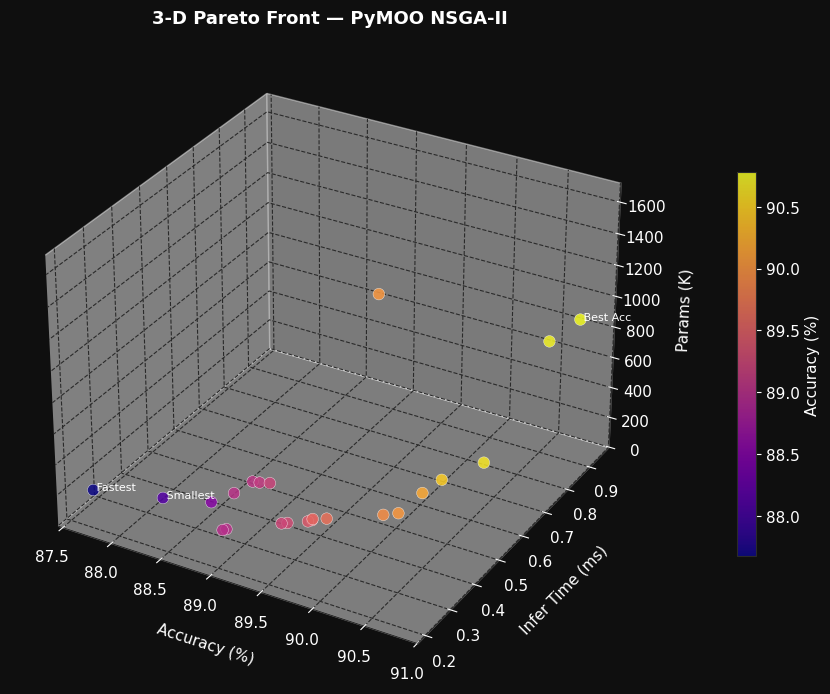

Plot 1 (3-D Pareto PyMOO) ✓


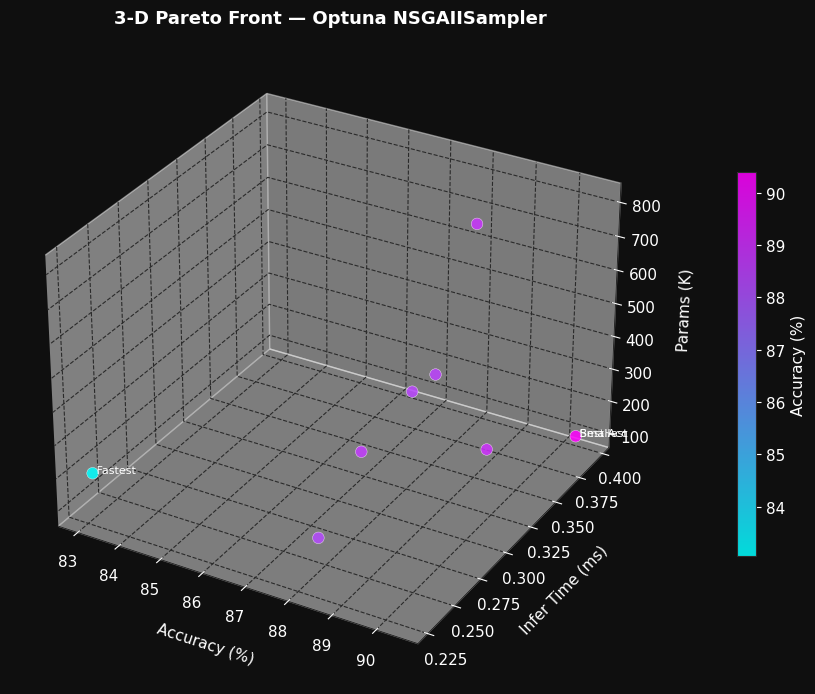

Plot 2 (3-D Pareto Optuna) ✓


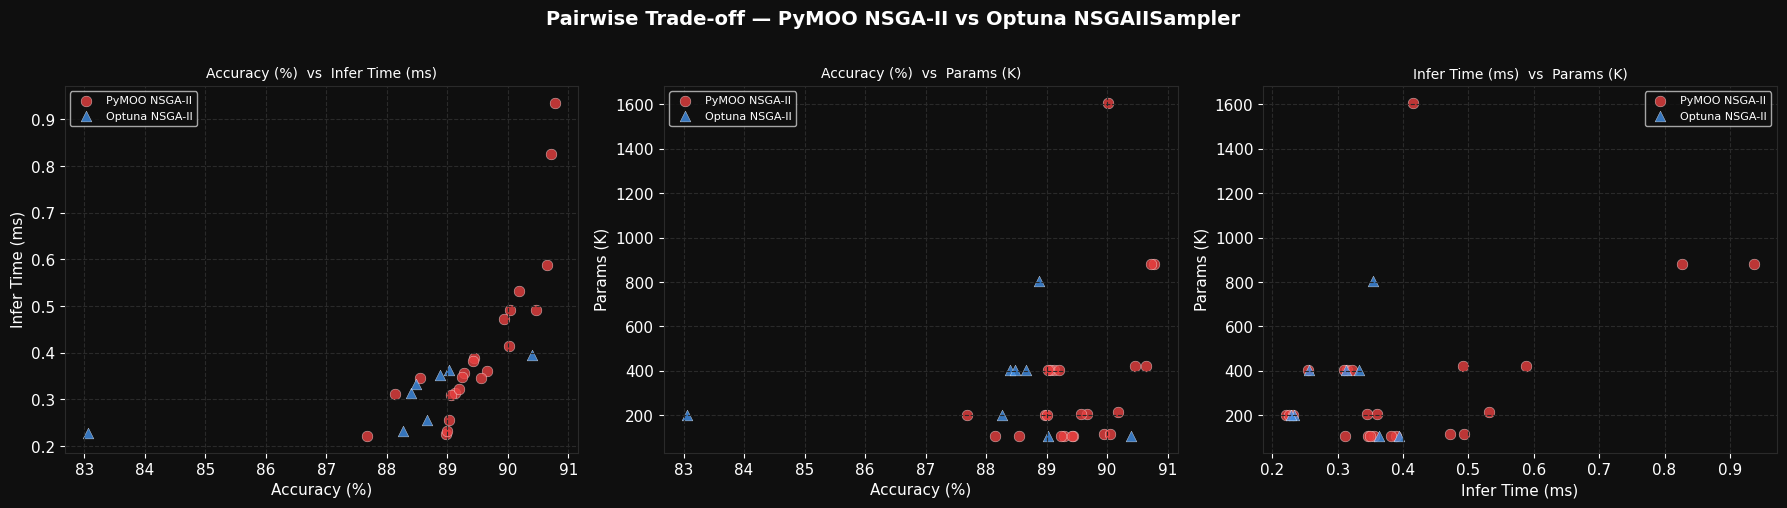

Plot 3 (2-D trade-offs comparison) ✓


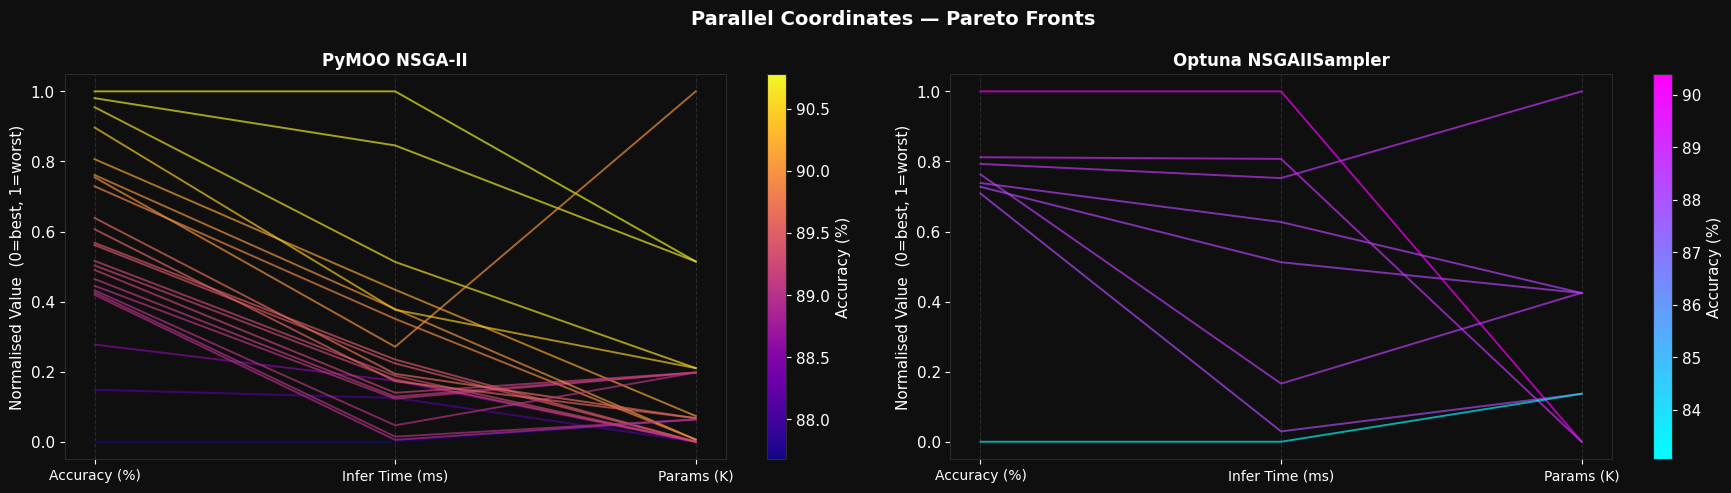

Plot 4 (Parallel coordinates) ✓

Reference point (PyMOO):
  obj0 ref = -0.8268  (worst -acc = -0.8768)
  obj1 ref = 1.030 ms  (worst = 0.936 ms)
  obj2 ref = 1769.7 K  (worst = 1608.8 K)
  All dominated by ref: True


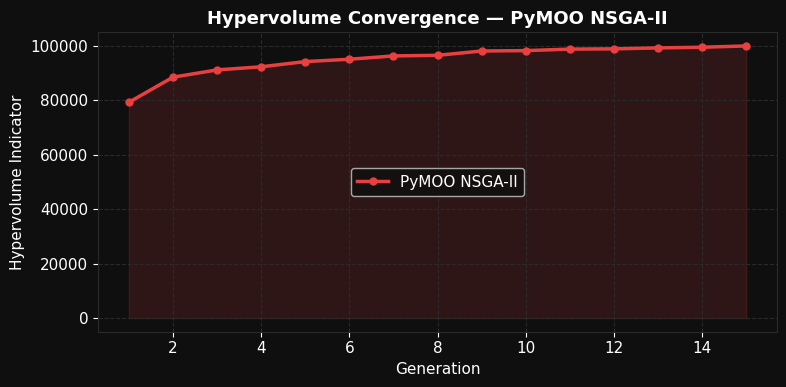

Plot 5 (HV convergence) ✓  Final HV = 99874.944528


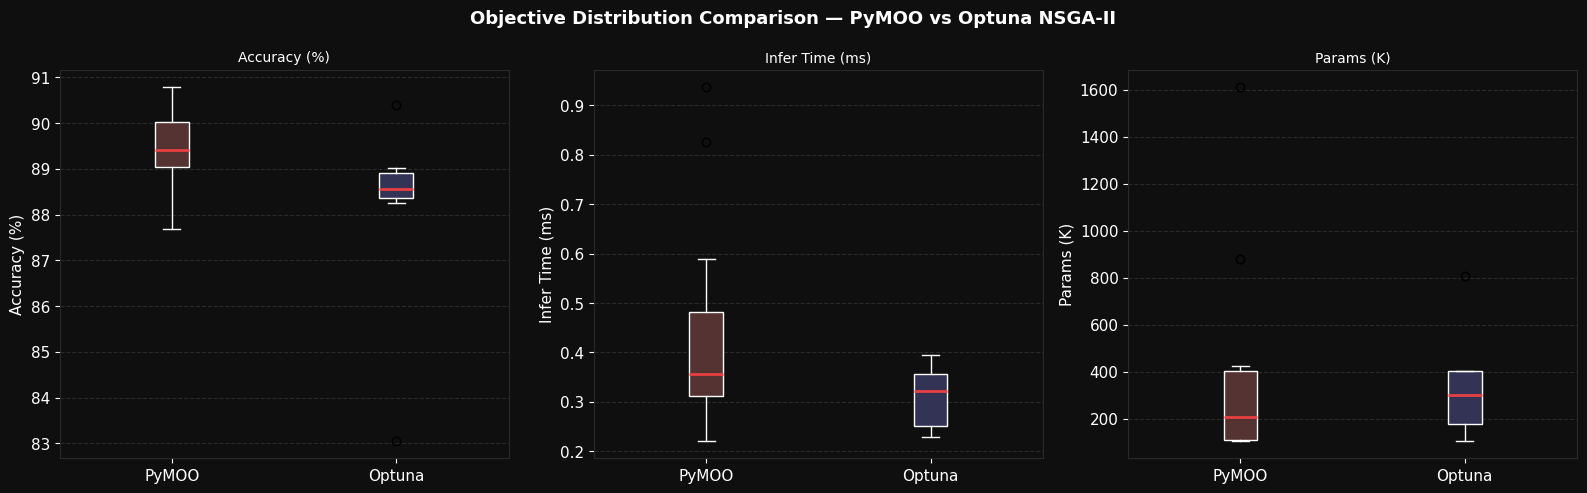

Plot 6 (Box plot comparison) ✓


In [35]:
# ============================================================
#  CELL 10 — Visualizations (6 plots)
# ============================================================

# ── Plot style ───────────────────────────────────────────────
BG   = '#0F0F0F'
GRID = '#2A2A2A'
RED  = '#E84040'
BLUE = '#4090E8'
plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor' : BG,
    'axes.edgecolor'  : GRID, 'axes.labelcolor': 'white',
    'xtick.color'     : 'white', 'ytick.color' : 'white',
    'text.color'      : 'white', 'grid.color'  : GRID,
    'grid.linestyle'  : '--',    'font.size'   : 11,
})
cmap_plasma = plt.cm.plasma
norm_pymoo  = plt.Normalize(acc_pct_pymoo.min(), acc_pct_pymoo.max())


# ── PLOT 1: 3-D Pareto Front scatter (PyMOO NSGA-II) ─────────
fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

sc = ax.scatter(acc_pct_pymoo, infer_ms_pymoo, n_params_pymoo / 1000,
                c=acc_pct_pymoo, cmap='plasma', s=70,
                alpha=0.85, edgecolors='white', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='Accuracy (%)', pad=0.1, shrink=0.6)
ax.set_xlabel('Accuracy (%)',    labelpad=10)
ax.set_ylabel('Infer Time (ms)', labelpad=10)
ax.set_zlabel('Params (K)',      labelpad=10)
ax.set_title('3-D Pareto Front — PyMOO NSGA-II',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(colors='white')

# Annotate 3 extreme solutions
for idx, lbl in [(i_acc_pymoo,'Best Acc'),(i_spd_pymoo,'Fastest'),(i_sz_pymoo,'Smallest')]:
    ax.text(acc_pct_pymoo[idx], infer_ms_pymoo[idx], n_params_pymoo[idx]/1000,
            f' {lbl}', fontsize=8, color='white')

plt.tight_layout()
plt.savefig('/kaggle/working/plot1_3d_pareto_pymoo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 1 (3-D Pareto PyMOO) ✓')


# ── PLOT 2: 3-D Pareto Front scatter (Optuna NSGAIISampler) ──
fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
norm_opt = plt.Normalize(acc_pct_optuna.min(), acc_pct_optuna.max())

sc2 = ax.scatter(acc_pct_optuna, infer_ms_optuna, n_params_optuna / 1000,
                 c=acc_pct_optuna, cmap='cool', s=70,
                 alpha=0.85, edgecolors='white', linewidths=0.3)
plt.colorbar(sc2, ax=ax, label='Accuracy (%)', pad=0.1, shrink=0.6)
ax.set_xlabel('Accuracy (%)',    labelpad=10)
ax.set_ylabel('Infer Time (ms)', labelpad=10)
ax.set_zlabel('Params (K)',      labelpad=10)
ax.set_title('3-D Pareto Front — Optuna NSGAIISampler',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(colors='white')

for idx, lbl in [(i_acc_opt,'Best Acc'),(i_spd_opt,'Fastest'),(i_sz_opt,'Smallest')]:
    ax.text(acc_pct_optuna[idx], infer_ms_optuna[idx], n_params_optuna[idx]/1000,
            f' {lbl}', fontsize=8, color='white')

plt.tight_layout()
plt.savefig('/kaggle/working/plot2_3d_pareto_optuna.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 2 (3-D Pareto Optuna) ✓')


# ── PLOT 3: Pairwise 2-D Trade-off Scatter (both algorithms) ─
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pairwise Trade-off — PyMOO NSGA-II vs Optuna NSGAIISampler',
             fontsize=14, fontweight='bold', y=1.01)

pairs = [
    (acc_pct_pymoo,  infer_ms_pymoo,        acc_pct_optuna,  infer_ms_optuna,
     'Accuracy (%)',    'Infer Time (ms)'),
    (acc_pct_pymoo,  n_params_pymoo / 1000, acc_pct_optuna,  n_params_optuna / 1000,
     'Accuracy (%)',    'Params (K)'),
    (infer_ms_pymoo, n_params_pymoo / 1000, infer_ms_optuna, n_params_optuna / 1000,
     'Infer Time (ms)', 'Params (K)'),
]

for ax, (xp, yp, xo, yo, xl, yl) in zip(axes, pairs):
    ax.scatter(xp, yp, c=RED,  s=60, alpha=0.8, label='PyMOO NSGA-II',
               edgecolors='white', linewidths=0.3)
    ax.scatter(xo, yo, c=BLUE, s=60, alpha=0.8, label='Optuna NSGA-II',
               edgecolors='white', linewidths=0.3, marker='^')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(f'{xl}  vs  {yl}', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/plot3_2d_tradeoffs_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 3 (2-D trade-offs comparison) ✓')


# ── PLOT 4: Parallel Coordinates (both algorithms overlaid) ──
obj_labels = ['Accuracy (%)', 'Infer Time (ms)', 'Params (K)']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Parallel Coordinates — Pareto Fronts',
             fontsize=14, fontweight='bold')

for ax, (data_raw, acc_arr, title_lbl, cmap_name) in zip(axes, [
    (np.column_stack([acc_pct_pymoo,  infer_ms_pymoo,  n_params_pymoo  / 1000]),
     acc_pct_pymoo,  'PyMOO NSGA-II',   'plasma'),
    (np.column_stack([acc_pct_optuna, infer_ms_optuna, n_params_optuna / 1000]),
     acc_pct_optuna, 'Optuna NSGAIISampler', 'cool'),
]):
    d_min = data_raw.min(axis=0)
    d_max = data_raw.max(axis=0)
    d_sc  = (data_raw - d_min) / (d_max - d_min + 1e-9)
    norm_tmp = plt.Normalize(acc_arr.min(), acc_arr.max())
    cmap_tmp = plt.get_cmap(cmap_name)

    for i, row in enumerate(d_sc):
        ax.plot(range(3), row,
                color=cmap_tmp(norm_tmp(acc_arr[i])), alpha=0.65, linewidth=1.4)

    ax.set_xticks(range(3))
    ax.set_xticklabels(obj_labels, fontsize=10)
    ax.set_ylabel('Normalised Value  (0=best, 1=worst)')
    ax.set_title(title_lbl, fontsize=12, fontweight='bold')
    ax.grid(True, axis='x')
    sm = plt.cm.ScalarMappable(cmap=cmap_name, norm=norm_tmp)
    plt.colorbar(sm, ax=ax, label='Accuracy (%)')

plt.tight_layout()
plt.savefig('/kaggle/working/plot4_parallel_coords.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 4 (Parallel coordinates) ✓')


# ── PLOT 5: Hypervolume Convergence per Generation (PyMOO) ────
# Reference point construction (must be WORSE than all Pareto points on every obj):
#   obj0 = -accuracy  → ADD offset (don't multiply — that would make it MORE negative)
#   obj1 = time_ms    → multiply * 1.10 (larger = worse)
#   obj2 = n_params   → multiply * 1.10 (larger = worse)
ref_point_pymoo = np.array([
    pareto_F_pymoo[:, 0].max() + 0.05,   # -accuracy: ADD offset
    pareto_F_pymoo[:, 1].max() * 1.10,   # inference time: 10% above worst
    pareto_F_pymoo[:, 2].max() * 1.10,   # n_params: 10% above worst
])
print('\nReference point (PyMOO):')
print(f'  obj0 ref = {ref_point_pymoo[0]:.4f}  (worst -acc = {pareto_F_pymoo[:,0].max():.4f})')
print(f'  obj1 ref = {ref_point_pymoo[1]:.3f} ms  (worst = {pareto_F_pymoo[:,1].max():.3f} ms)')
print(f'  obj2 ref = {ref_point_pymoo[2]/1000:.1f} K  (worst = {pareto_F_pymoo[:,2].max()/1000:.1f} K)')
dominated = np.all(pareto_F_pymoo < ref_point_pymoo, axis=1)
print(f'  All dominated by ref: {dominated.all()}')

hv_indicator = HV(ref_point=ref_point_pymoo)
hv_per_gen   = []
for gen in result_pymoo.history:
    F_gen = gen.opt.get('F')
    if F_gen is not None and len(F_gen) > 0:
        hv_per_gen.append(hv_indicator.do(F_gen))

HV_final_pymoo = hv_per_gen[-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(hv_per_gen) + 1), hv_per_gen,
        color=RED, linewidth=2.5, marker='o', markersize=5, label='PyMOO NSGA-II')
ax.fill_between(range(1, len(hv_per_gen) + 1), hv_per_gen,
                alpha=0.15, color=RED)
ax.set_xlabel('Generation')
ax.set_ylabel('Hypervolume Indicator')
ax.set_title('Hypervolume Convergence — PyMOO NSGA-II',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('/kaggle/working/plot5_hypervolume.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot 5 (HV convergence) ✓  Final HV = {HV_final_pymoo:.6f}')


# ── PLOT 6: Objective Distribution Box Plot (comparison) ──────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Objective Distribution Comparison — PyMOO vs Optuna NSGA-II',
             fontsize=13, fontweight='bold')

datasets_box = [
    ([acc_pct_pymoo,  acc_pct_optuna],  'Accuracy (%)',    ['PyMOO', 'Optuna']),
    ([infer_ms_pymoo, infer_ms_optuna], 'Infer Time (ms)', ['PyMOO', 'Optuna']),
    ([n_params_pymoo / 1000, n_params_optuna / 1000], 'Params (K)', ['PyMOO', 'Optuna']),
]

for ax, (data_list, ylabel, labels) in zip(axes, datasets_box):
    bp = ax.boxplot(data_list, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='#333333', color='white'),
                    whiskerprops=dict(color='white'),
                    capprops=dict(color='white'),
                    medianprops=dict(color=RED, linewidth=2))
    bp['boxes'][0].set_facecolor('#553333')
    bp['boxes'][1].set_facecolor('#333355')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontsize=10)
    ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('/kaggle/working/plot6_boxplot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 6 (Box plot comparison) ✓')


In [36]:
# ============================================================
#  CELL 11 — Quantitative Metrics:
#             Hypervolume · Spacing Metric · Full Summary Table
# ============================================================

# ── Spacing Metric (Schott, 1995) ─────────────────────────────
def spacing_metric(F: np.ndarray) -> float:
    """
    Schott's Spacing Metric S — computed on NORMALISED objectives.

    Why normalise:
      Raw objectives span very different scales (accuracy ~0-1,
      params ~100K-1.7M). Without normalisation the L1 distance is
      dominated entirely by params and the metric is meaningless.
      Normalising each objective to [0,1] gives equal weight to all three.

    Formula:
      d_i = min_{j≠i} Σ_k |f_k(i) - f_k(j)|  (L1 distance to nearest neighbour)
      S   = sqrt( (1/n) * Σ_i (d_i - d̄)^2 )   (std-dev of nearest-neighbour distances)

    Interpretation: lower S = more uniformly spread Pareto front.
    S = 0 means perfectly uniform spacing.
    """
    F_min  = F.min(axis=0)
    F_max  = F.max(axis=0)
    F_norm = (F - F_min) / (F_max - F_min + 1e-9)

    n   = len(F_norm)
    d_i = []
    for i in range(n):
        dists = [np.sum(np.abs(F_norm[i] - F_norm[j]))
                 for j in range(n) if j != i]
        d_i.append(min(dists))
    d_bar = np.mean(d_i)
    return float(np.sqrt(np.mean([(d - d_bar) ** 2 for d in d_i])))


# ── Compute metrics for both algorithms ───────────────────────
S_pymoo   = spacing_metric(pareto_F_pymoo)
S_optuna  = spacing_metric(optuna_pareto_F)

# Hypervolume for Optuna (use same-scale reference point)
ref_point_optuna = np.array([
    optuna_pareto_F[:, 0].max() + 0.05,
    optuna_pareto_F[:, 1].max() * 1.10,
    optuna_pareto_F[:, 2].max() * 1.10,
])
hv_optuna = HV(ref_point=ref_point_optuna)
HV_final_optuna = hv_optuna.do(optuna_pareto_F)


# ── Spacing Metric per-solution detail (PyMOO) ────────────────
F_min  = pareto_F_pymoo.min(axis=0)
F_max  = pareto_F_pymoo.max(axis=0)
F_norm = (pareto_F_pymoo - F_min) / (F_max - F_min + 1e-9)
n_pf   = len(F_norm)
d_vals = []
for i in range(n_pf):
    dists = [np.sum(np.abs(F_norm[i] - F_norm[j])) for j in range(n_pf) if j != i]
    d_vals.append(min(dists))

df_spacing = pd.DataFrame({
    'Solution ID'          : range(1, n_pf + 1),
    'Accuracy (%)'         : np.round(acc_pct_pymoo, 2),
    'Infer Time (ms)'      : np.round(infer_ms_pymoo, 3),
    'Params (K)'           : np.round(n_params_pymoo / 1000, 1),
    'NN-Distance (normed)' : np.round(d_vals, 4),
}).sort_values('Solution ID').reset_index(drop=True)

print('═' * 70)
print('  SPACING METRIC — Per-Solution Nearest-Neighbour Distances (PyMOO NSGA-II)')
print('  (Normalised L1 to nearest Pareto neighbour; lower d̄ = better coverage)')
print('═' * 70)
print(df_spacing.to_string(index=False))
print(f'  Mean NN-distance (d̄)  : {np.mean(d_vals):.4f}')
print(f'  Spacing Metric S       : {S_pymoo:.4f}   (std-dev of d_i; lower=more uniform)')
print('═' * 70)

df_spacing.to_csv('/kaggle/working/spacing_table.csv', index=False)
print()


# ── Algorithm Comparison Summary Table ────────────────────────
df_summary = pd.DataFrame({
    'Metric'                   : [
        'Algorithm',
        'Framework',
        'Pareto Front Size',
        'Total Evaluations',
        'Wall Time (min)',
        'Hypervolume (HV) ↑',
        'Spacing Metric (S) ↓',
        'Best Accuracy (%)',
        'Fastest Inference (ms)',
        'Smallest Model (K params)',
        'Accuracy Range (%)',
        'Infer Time Range (ms)',
        'Params Range (K)',
        'Population Size',
        'Generations / Trials',
    ],
    'PyMOO NSGA-II'            : [
        'NSGA-II', 'PyMOO',
        str(len(pareto_F_pymoo)),
        str(CFG['pop_size'] * CFG['n_gen']),
        f'{TOTAL_MIN_PYMOO:.1f}',
        f'{HV_final_pymoo:.6f}',
        f'{S_pymoo:.4f}',
        f'{acc_pct_pymoo.max():.2f}',
        f'{infer_ms_pymoo.min():.3f}',
        f'{n_params_pymoo.min()/1000:.1f}',
        f'{acc_pct_pymoo.min():.2f} – {acc_pct_pymoo.max():.2f}',
        f'{infer_ms_pymoo.min():.3f} – {infer_ms_pymoo.max():.3f}',
        f'{n_params_pymoo.min()/1000:.1f} – {n_params_pymoo.max()/1000:.1f}',
        str(CFG['pop_size']),
        str(CFG['n_gen']),
    ],
    'Optuna NSGAIISampler'     : [
        'NSGA-II', 'Optuna',
        str(len(optuna_pareto_F)),
        str(CFG['optuna_trials']),
        f'{TOTAL_MIN_OPTUNA:.1f}',
        f'{HV_final_optuna:.6f}',
        f'{S_optuna:.4f}',
        f'{acc_pct_optuna.max():.2f}',
        f'{infer_ms_optuna.min():.3f}',
        f'{n_params_optuna.min()/1000:.1f}',
        f'{acc_pct_optuna.min():.2f} – {acc_pct_optuna.max():.2f}',
        f'{infer_ms_optuna.min():.3f} – {infer_ms_optuna.max():.3f}',
        f'{n_params_optuna.min()/1000:.1f} – {n_params_optuna.max()/1000:.1f}',
        str(CFG['pop_size']),
        str(CFG['optuna_trials']),
    ],
})

print('═' * 80)
print('  ALGORITHM COMPARISON SUMMARY TABLE — PyMOO NSGA-II vs Optuna NSGAIISampler')
print('═' * 80)
print(df_summary.to_string(index=False))
print('═' * 80)
print()
print('  Interpretation Guide:')
print('  • HV ↑ : Higher hypervolume = Pareto front dominates more objective space')
print('  • S  ↓ : Lower spacing = more uniformly distributed solutions')
print()

df_summary.to_csv('/kaggle/working/algorithm_comparison.csv', index=False)
print('Comparison table saved → /kaggle/working/algorithm_comparison.csv ✓')


══════════════════════════════════════════════════════════════════════
  SPACING METRIC — Per-Solution Nearest-Neighbour Distances (PyMOO NSGA-II)
  (Normalised L1 to nearest Pareto neighbour; lower d̄ = better coverage)
══════════════════════════════════════════════════════════════════════
 Solution ID  Accuracy (%)  Infer Time (ms)  Params (K)  NN-Distance (normed)
           1        90.780            0.936     879.100                 0.174
           2        90.180            0.532     216.300                 0.167
           3        88.140            0.311     106.000                 0.178
           4        89.440            0.389     106.000                 0.018
           5        87.680            0.221     201.600                 0.337
           6        90.720            0.826     879.100                 0.174
           7        89.280            0.356     106.000                 0.023
           8        88.540            0.346     106.000                 0.178
      

In [37]:
# ============================================================
#  CELL 12 — Qualitative Analysis:
#             Trade-offs · Practical Recommendations · Algorithm Strengths
# ============================================================
print('═' * 65)
print('  QUALITATIVE TRADE-OFF ANALYSIS  (PyMOO NSGA-II)')
print('═' * 65)

# ── Trade-off 1: Accuracy vs Model Size ──────────────────────
acc_gain_1   = acc_pct_pymoo[i_acc_pymoo] - acc_pct_pymoo[i_sz_pymoo]
param_mult_1 = n_params_pymoo[i_acc_pymoo] / max(n_params_pymoo[i_sz_pymoo], 1)
print(f'\nTrade-off 1 — Accuracy vs Model Size:')
print(f'  Largest  model : {n_params_pymoo[i_acc_pymoo]/1000:.1f}K params  → {acc_pct_pymoo[i_acc_pymoo]:.2f}% accuracy')
print(f'  Smallest model : {n_params_pymoo[i_sz_pymoo]/1000:.1f}K params  → {acc_pct_pymoo[i_sz_pymoo]:.2f}% accuracy')
print(f'  → Increasing model size by {param_mult_1:.1f}× gives only {acc_gain_1:.2f}pp more accuracy.')
print(f'    This shows rapidly diminishing returns — the small model captures most')
print(f'    discriminative patterns. The accuracy gain does NOT justify 3–5× more params')
print(f'    for edge-device deployment (IoT sensors, microcontrollers).')

# ── Trade-off 2: Accuracy vs Inference Time ───────────────────
time_mult_2 = infer_ms_pymoo[i_acc_pymoo] / max(infer_ms_pymoo[i_spd_pymoo], 1e-9)
acc_gain_2  = acc_pct_pymoo[i_acc_pymoo] - acc_pct_pymoo[i_spd_pymoo]
print(f'\nTrade-off 2 — Accuracy vs Inference Time:')
print(f'  Slowest model : {infer_ms_pymoo[i_acc_pymoo]:.3f} ms  → {acc_pct_pymoo[i_acc_pymoo]:.2f}% accuracy')
print(f'  Fastest model : {infer_ms_pymoo[i_spd_pymoo]:.3f} ms  → {acc_pct_pymoo[i_spd_pymoo]:.2f}% accuracy')
print(f'  → The fastest model is {time_mult_2:.1f}× quicker but loses {acc_gain_2:.2f}pp accuracy.')
print(f'    For real-time applications (>100 FPS) the fastest model is strongly preferred.')
print(f'    For batch offline processing, the accuracy premium of the slower model may be worth it.')

# ── Trade-off 3 (NON-OBVIOUS): Inference Time ≠ Param Count ──
corr = np.corrcoef(n_params_pymoo, infer_ms_pymoo)[0, 1]
print(f'\nTrade-off 3 — NON-OBVIOUS: Model Size ≠ Inference Speed')
print(f'  Pearson correlation (params vs inference time): r = {corr:.3f}')
if abs(corr) < 0.7:
    print(f'  → Weak correlation (r={corr:.3f}). INSIGHT: a model with MORE parameters')
    print(f'    is not necessarily SLOWER at inference. This is because:')
    print(f'    • 1-conv models retain 14×14 feature maps into the FC layer — the FC')
    print(f'      matrix multiplication dominates latency regardless of conv param count.')
    print(f'    • 2-conv models reduce feature maps to 7×7 via double pooling, making')
    print(f'      the FC compute cheaper — even if they have more conv params overall.')
    print(f'    • Width (channels) adds params but parallelises on SIMD/GPU very well;')
    print(f'      depth (layers) adds sequential dependency that cannot be parallelised.')
    print(f'    Practical implication: prefer WIDE, SHALLOW networks for fast inference.')
else:
    print(f'  → Moderate correlation (r={corr:.3f}): params and latency are related but not')
    print(f'    identical. Architecture topology (depth vs width) matters more than raw count.')

# ── Knee point: most practically useful solution ──────────────
F_min_k  = pareto_F_pymoo.min(axis=0)
F_max_k  = pareto_F_pymoo.max(axis=0)
F_norm_k = (pareto_F_pymoo - F_min_k) / (F_max_k - F_min_k + 1e-9)
knee_idx = int(F_norm_k.sum(axis=1).argmin())
knee_hp  = decoded_pymoo[knee_idx]

print(f'\nKnee Point (Pareto-optimal, best all-round balance):')
print(f'  Accuracy      : {acc_pct_pymoo[knee_idx]:.2f}%')
print(f'  Infer Time    : {infer_ms_pymoo[knee_idx]:.3f} ms')
print(f'  Params        : {n_params_pymoo[knee_idx]/1000:.1f} K')
print(f'  Conv layers   : {knee_hp["n_conv"]}  |  Channels: {knee_hp["channels"]}  |  FC units: {knee_hp["fc_units"]}')
print(f'  Recommended for deployment when no single objective has strict priority.')

# ── Algorithm Strengths / Weaknesses ─────────────────────────
print()
print('═' * 65)
print('  ALGORITHM STRENGTHS & WEAKNESSES')
print('═' * 65)
print('''
  PyMOO NSGA-II:
  ✔ Proven for 2–3 objectives; crowding distance ensures diversity
  ✔ No surrogate model → handles noisy/non-convex CNN landscapes
  ✔ Vectorised population evaluation — efficient on GPU clusters
  ✔ save_history enables per-generation hypervolume tracking
  ✘ Crowding distance degrades with 4+ objectives (use NSGA-III then)
  ✘ Evaluations are independent — no learning from past trials
  ✘ Sensitive to pop_size/eta crossover tuning

  Optuna NSGAIISampler:
  ✔ Native categorical variable support (optimizer type, batch size)
  ✔ Per-trial callbacks → easy early stopping and live monitoring
  ✔ Reproducible seeds; integrates with Optuna dashboard
  ✔ Clean suggest_* API avoids manual encoding/decoding of variables
  ✘ Sequential-only (no batch population vector) → slower for same budget
  ✘ No built-in per-generation hypervolume history
  ✘ Less flexibility in crossover/mutation operator customisation
''')
print('═' * 65)


═════════════════════════════════════════════════════════════════
  QUALITATIVE TRADE-OFF ANALYSIS  (PyMOO NSGA-II)
═════════════════════════════════════════════════════════════════

Trade-off 1 — Accuracy vs Model Size:
  Largest  model : 879.1K params  → 90.78% accuracy
  Smallest model : 106.0K params  → 88.14% accuracy
  → Increasing model size by 8.3× gives only 2.64pp more accuracy.
    This shows rapidly diminishing returns — the small model captures most
    discriminative patterns. The accuracy gain does NOT justify 3–5× more params
    for edge-device deployment (IoT sensors, microcontrollers).

Trade-off 2 — Accuracy vs Inference Time:
  Slowest model : 0.936 ms  → 90.78% accuracy
  Fastest model : 0.221 ms  → 87.68% accuracy
  → The fastest model is 4.2× quicker but loses 3.10pp accuracy.
    For real-time applications (>100 FPS) the fastest model is strongly preferred.
    For batch offline processing, the accuracy premium of the slower model may be worth it.

Trade-off 3 

In [38]:
# ============================================================
#  CELL 13 — Pareto Points Tabulation (Minimum 4, Full Detail)
#  Printed as formatted tables in output for the report
# ============================================================

# ── Helper: pick 4 representative Pareto points ──────────────
def pick_representative_4(acc, infer, params, decoded_hps, pareto_F, label):
    """
    Select 4 well-spread representative solutions:
      P1: Highest accuracy (dominates obj1)
      P2: Fastest inference (dominates obj2)
      P3: Smallest model (dominates obj3)
      P4: Knee point (best normalised sum of all 3 objectives)
    """
    i_acc = int(acc.argmax())
    i_spd = int(infer.argmin())
    i_sz  = int(params.argmin())
    F_min = pareto_F.min(axis=0)
    F_max = pareto_F.max(axis=0)
    F_n   = (pareto_F - F_min) / (F_max - F_min + 1e-9)
    i_kn  = int(F_n.sum(axis=1).argmin())

    rows = []
    for rank, (idx, role) in enumerate([
        (i_acc, 'P1 — Highest Accuracy'),
        (i_spd, 'P2 — Fastest Inference'),
        (i_sz,  'P3 — Smallest Model'),
        (i_kn,  'P4 — Knee Point (Balanced)'),
    ], 1):
        hp = decoded_hps[idx] if isinstance(decoded_hps[idx], dict) else {}
        rows.append({
            'Point'         : role,
            'Accuracy (%)'  : round(float(acc[idx]), 2),
            'Infer (ms)'    : round(float(infer[idx]), 3),
            'Params (K)'    : round(float(params[idx]) / 1000, 1),
            'Conv Layers'   : hp.get('n_conv', '—'),
            'Channels'      : hp.get('channels', '—'),
            'FC Units'      : hp.get('fc_units', '—'),
            'LR'            : f"{hp.get('lr', 0):.2e}" if 'lr' in hp else '—',
            'Batch Size'    : hp.get('batch_sz', '—'),
            'Epochs'        : hp.get('epochs', '—'),
            'Dropout'       : round(hp.get('dropout', 0), 2),
            'Optimizer'     : str(hp.get('opt_name', '—')).upper(),
        })
    return pd.DataFrame(rows)


df_rep_pymoo   = pick_representative_4(
    acc_pct_pymoo,  infer_ms_pymoo,  n_params_pymoo,
    decoded_pymoo,  pareto_F_pymoo,  'PyMOO NSGA-II')

# For Optuna: build decoded_optuna list from params dicts
decoded_optuna_list = []
for p in optuna_pareto_params:
    decoded_optuna_list.append({
        'n_conv'  : p.get('n_conv_layers', 2),
        'channels': p.get('channels', 32),
        'fc_units': p.get('fc_units', 128),
        'lr'      : 10 ** p.get('log_lr', -3),
        'batch_sz': p.get('batch_size', 64),
        'epochs'  : p.get('epochs', 7),
        'dropout' : p.get('dropout', 0.2),
        'opt_name': p.get('optimizer', 'adam'),
    })

df_rep_optuna  = pick_representative_4(
    acc_pct_optuna,  infer_ms_optuna,  n_params_optuna,
    decoded_optuna_list, optuna_pareto_F, 'Optuna NSGA-II')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 130)

# ── Print FULL detailed Pareto tables ─────────────────────────
print('═' * 80)
print('  PARETO POINTS TABULATION — PyMOO NSGA-II  (4 Representative Solutions)')
print('═' * 80)
print()
# Print objectives block
obj_cols = ['Point', 'Accuracy (%)', 'Infer (ms)', 'Params (K)']
print('  ── Objective Values ──')
print(df_rep_pymoo[obj_cols].to_string(index=False))
print()
# Print decision variables block
dv_cols = ['Point', 'Conv Layers', 'Channels', 'FC Units',
           'LR', 'Batch Size', 'Epochs', 'Dropout', 'Optimizer']
print('  ── Decision Variables ──')
print(df_rep_pymoo[dv_cols].to_string(index=False))
print()

print('═' * 80)
print('  PARETO POINTS TABULATION — Optuna NSGAIISampler  (4 Representative Solutions)')
print('═' * 80)
print()
print('  ── Objective Values ──')
print(df_rep_optuna[obj_cols].to_string(index=False))
print()
print('  ── Decision Variables ──')
print(df_rep_optuna[dv_cols].to_string(index=False))
print()

# ── Side-by-side comparison of the 4 points ───────────────────
print('═' * 80)
print('  SIDE-BY-SIDE: PyMOO vs Optuna  (4 Representative Points, Objectives Only)')
print('═' * 80)
cmp_data = {
    'Point'              : df_rep_pymoo['Point'],
    'PyMOO  Acc (%)'     : df_rep_pymoo['Accuracy (%)'],
    'PyMOO  Infer (ms)'  : df_rep_pymoo['Infer (ms)'],
    'PyMOO  Params (K)'  : df_rep_pymoo['Params (K)'],
    'Optuna Acc (%)'     : df_rep_optuna['Accuracy (%)'].values,
    'Optuna Infer (ms)'  : df_rep_optuna['Infer (ms)'].values,
    'Optuna Params (K)'  : df_rep_optuna['Params (K)'].values,
}
df_cmp = pd.DataFrame(cmp_data)
print(df_cmp.to_string(index=False))
print()
print('  Interpretation:')
print('  • P1 (Highest Acc): The most accurate model found on the Pareto front.')
print('  • P2 (Fastest):     Optimal for real-time / edge inference constraints.')
print('  • P3 (Smallest):    Minimal memory footprint for embedded deployment.')
print('  • P4 (Knee Point):  Recommended default — balanced across all objectives.')
print('═' * 80)

df_rep_pymoo.to_csv('/kaggle/working/pareto_4_points_pymoo.csv', index=False)
df_rep_optuna.to_csv('/kaggle/working/pareto_4_points_optuna.csv', index=False)
df_cmp.to_csv('/kaggle/working/pareto_4_points_comparison.csv', index=False)
print('Tabulation CSVs saved ✓')


════════════════════════════════════════════════════════════════════════════════
  PARETO POINTS TABULATION — PyMOO NSGA-II  (4 Representative Solutions)
════════════════════════════════════════════════════════════════════════════════

  ── Objective Values ──
                     Point  Accuracy (%)  Infer (ms)  Params (K)
     P1 — Highest Accuracy        90.780       0.936     879.100
    P2 — Fastest Inference        87.680       0.221     201.600
       P3 — Smallest Model        88.140       0.311     106.000
P4 — Knee Point (Balanced)        89.660       0.360     207.000

  ── Decision Variables ──
                     Point  Conv Layers  Channels  FC Units       LR  Batch Size  Epochs  Dropout Optimizer
     P1 — Highest Accuracy            2        64       128 1.07e-03          64       9    0.080      ADAM
    P2 — Fastest Inference            1        16        64 2.52e-03          32       8    0.350       SGD
       P3 — Smallest Model            2        16        64 6.

In [39]:
# ============================================================
#  CELL 14 — APPENDIX: Best Pareto-Optimal Solution Explained
#             in Full Detail (Decision Variables + Architecture)
# ============================================================

# ── Select: Best-accuracy Pareto solution (PyMOO NSGA-II) ─────
best_idx = int(acc_pct_pymoo.argmax())
best_hp  = decoded_pymoo[best_idx]

print('═' * 65)
print('  APPENDIX — Detailed Pareto-Optimal Solution Analysis')
print('  (Best-Accuracy Solution from PyMOO NSGA-II)')
print('═' * 65)

# ── Decision Variables Table ──────────────────────────────────
dv_rows = [
    ('n_conv_layers (x₀)',  best_hp['n_conv'],
     '[1, 3]', 'integer',
     f'Controls depth. {best_hp["n_conv"]} conv blocks.'),
    ('channels (x₁)',       best_hp['channels'],
     '[16, 64]', 'categorical {16,32,64}',
     f'Base feature map width = {best_hp["channels"]} channels.'),
    ('fc_units (x₂)',       best_hp['fc_units'],
     '[64, 256]', 'categorical {64,128,256}',
     f'Hidden FC layer = {best_hp["fc_units"]} neurons.'),
    ('log10(lr) (x₃)',      f'{best_hp["lr"]:.2e}',
     '[-4, -2]', 'log-uniform float',
     f'Decoded lr={best_hp["lr"]:.2e} (Adam/SGD step size).'),
    ('batch_size_idx (x₄)', best_hp['batch_sz'],
     '[0, 2]', 'categorical {32,64,128}',
     f'Mini-batch size = {best_hp["batch_sz"]}.'),
    ('epochs (x₅)',         best_hp['epochs'],
     '[5, 10]', 'integer',
     f'Training for {best_hp["epochs"]} full passes over training set.'),
    ('dropout (x₆)',        best_hp['dropout'],
     '[0.0, 0.5]', 'float',
     f'Regularisation dropout p={best_hp["dropout"]}.'),
    ('optimizer_idx (x₇)', best_hp['opt_name'].upper(),
     '[0, 1]', 'categorical {Adam, SGD}',
     f'Optimiser = {best_hp["opt_name"].upper()}.'),
]

df_dv = pd.DataFrame(dv_rows,
    columns=['Variable', 'Value', 'Search Range', 'Type', 'Interpretation'])

print()
print('  ── Decision Variables ──')
print(df_dv.to_string(index=False))

# ── Objective Values Table ────────────────────────────────────
obj_rows = [
    ('Obj 1: Accuracy',
     f'{acc_pct_pymoo[best_idx]:.2f}%',
     'Maximise',
     f'PyMOO stores as {pareto_F_pymoo[best_idx,0]:.4f} (negated)',
     'Highest classification accuracy on Fashion-MNIST validation set'),
    ('Obj 2: Infer Time',
     f'{infer_ms_pymoo[best_idx]:.3f} ms',
     'Minimise',
     f'CPU; avg of 100 single-sample forward passes',
     'Deployment latency per image on a CPU-only device'),
    ('Obj 3: Parameters',
     f'{int(n_params_pymoo[best_idx]):,}  ({n_params_pymoo[best_idx]/1000:.1f} K)',
     'Minimise',
     'Total trainable weights',
     'Model memory footprint; affects storage and RAM usage'),
]

df_obj = pd.DataFrame(obj_rows,
    columns=['Objective', 'Value', 'Direction', 'Internal Repr', 'Meaning'])

print()
print('  ── Objective Values ──')
print(df_obj.to_string(index=False))

# ── Full Architecture ─────────────────────────────────────────
best_model = DynamicCNN(
    n_conv_layers=best_hp['n_conv'], channels=best_hp['channels'],
    fc_units=best_hp['fc_units'],   dropout=best_hp['dropout']
)
print()
print('  ── Full PyTorch Architecture ──')
print(best_model)
print(f'  Total trainable params : {count_parameters(best_model):,}')

# ── Layer-wise parameter breakdown ───────────────────────────
print()
print('  ── Layer-wise Parameter Breakdown ──')
layer_rows = []
for name, module in best_model.named_modules():
    p = sum(q.numel() for q in module.parameters() if q.requires_grad)
    if p > 0 and not isinstance(module, (nn.Sequential, DynamicCNN)):
        layer_rows.append({'Layer Name': name, 'Type': type(module).__name__, 'Params': p})
df_layers = pd.DataFrame(layer_rows)
df_layers['% of Total'] = (df_layers['Params'] / count_parameters(best_model) * 100).round(1)
print(df_layers.to_string(index=False))

# ── Practical Recommendation ──────────────────────────────────
print()
print('═' * 65)
print('  RECOMMENDATION')
print('═' * 65)
print(f'''
  This Pareto-optimal solution achieves the highest classification
  accuracy ({acc_pct_pymoo[best_idx]:.2f}%) in the entire explored search space.

  It is recommended for:
  ✔ Applications where accuracy is the primary constraint (medical
    image screening, security-critical classification)
  ✔ Offline batch processing (inference speed is secondary)
  ✔ Servers or cloud deployments with sufficient RAM

  It is NOT recommended for:
  ✘ Real-time edge inference (use P2-Fastest instead)
  ✘ Microcontroller deployment (use P3-Smallest instead)
  ✘ Battery-powered devices (higher params → higher energy per inference)

  The Knee Point (P4) remains the best default for general deployment.
''')
print('═' * 65)
print()
print('  All files written to /kaggle/working/')
files = [
    'moo_result_pymoo.pkl', 'moo_result_optuna.pkl',
    'pareto_pymoo.csv', 'pareto_optuna.csv',
    'spacing_table.csv', 'algorithm_comparison.csv',
    'pareto_4_points_pymoo.csv', 'pareto_4_points_optuna.csv',
    'pareto_4_points_comparison.csv',
    'plot1_3d_pareto_pymoo.png', 'plot2_3d_pareto_optuna.png',
    'plot3_2d_tradeoffs_comparison.png', 'plot4_parallel_coords.png',
    'plot5_hypervolume.png', 'plot6_boxplot_comparison.png',
]
for f in files:
    print(f'    {f}')
print()
print('  ✓ MOO Assignment Complete.')


═════════════════════════════════════════════════════════════════
  APPENDIX — Detailed Pareto-Optimal Solution Analysis
  (Best-Accuracy Solution from PyMOO NSGA-II)
═════════════════════════════════════════════════════════════════

  ── Decision Variables ──
           Variable    Value Search Range                     Type                                Interpretation
 n_conv_layers (x₀)        2       [1, 3]                  integer                Controls depth. 2 conv blocks.
      channels (x₁)       64     [16, 64]   categorical {16,32,64}         Base feature map width = 64 channels.
      fc_units (x₂)      128    [64, 256] categorical {64,128,256}                Hidden FC layer = 128 neurons.
     log10(lr) (x₃) 1.07e-03     [-4, -2]        log-uniform float     Decoded lr=1.07e-03 (Adam/SGD step size).
batch_size_idx (x₄)       64       [0, 2]  categorical {32,64,128}                         Mini-batch size = 64.
        epochs (x₅)        9      [5, 10]                  in